<a href="https://colab.research.google.com/github/karolalonso70-dev/Estad-sticaVerano2026/blob/main/hp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/Casa_toluca.csv")

df.head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Ubicación,Area,Baños,Habitaciones,Precio
0,0,0,0,"Casa en Venta Los Serrados\n, Toluca De Lerdo,...",105.0,2.0,3.0,130000.0
1,1,1,1,"Casa en Venta Tierra Y Libertad #114\n, Toluca...",115.0,2.0,3.0,50800.0
2,2,2,2,"Casa en Venta Toluca De Lerdo, México",700.0,3.0,3.0,325000.0
3,3,3,3,"Casa en Venta Granjas, Toluca De Lerdo",390.0,3.0,4.0,275000.0
4,4,4,4,"Casa en Venta Toluca De Lerdo, México",300.0,4.0,3.0,215000.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.2  2004 non-null   int64  
 1   Unnamed: 0    2004 non-null   int64  
 2   Unnamed: 0.1  2004 non-null   int64  
 3   Ubicación     2004 non-null   object 
 4   Area          1721 non-null   float64
 5   Baños         1950 non-null   float64
 6   Habitaciones  1931 non-null   float64
 7   Precio        1999 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 125.4+ KB


In [3]:
df.dropna(inplace=True)

+ `Hours_Studied` es del tipo entero.
+ `Previous_Scores`es del tipo entero.
+ `Extracurricular_Activities` es del tipo categórica.
+ `Sleep_Hours` es del tipo numérico entero.
+ `Sample_Question_Papers_Practiced` numérico entero.
+ `Peformance_Index` es del tipo numérico con decimales.

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
group1 group2    meandiff   p-adj      lower        upper     reject
--------------------------------------------------------------------
   1.0   10.0      338360.0    1.0 -1043343.3907 1720063.3907  False
   1.0   12.0      253360.0    1.0 -1128343.3907 1635063.3907  False
   1.0   14.0      775860.0 0.3928  -244595.5827 1796315.5827  False
   1.0   17.0      863360.0  0.736  -518343.3907 2245063.3907  False
   1.0   18.0     1363360.0 0.0577   -18343.3907 2745063.3907  False
   1.0    2.0    27289.3045    1.0  -397337.6411  451916.2501  False
   1.0   20.0      418860.0 0.9997  -962843.3907 1800563.3907  False
   1.0    3.0    74754.3502    1.0  -343952.1398  493460.8401  False
   1.0    4.0   183052.6384 0.9846  -240999.7802  607105.0571  False
   1.0   40.0      418860.0 0.9997  -962843.3907 1800563.3907  False
   1.0    5.0   232838.1933 0.9204  -213769.7489  679446.1355  False
   1.0    6.0  1056362.0236    0.0

Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

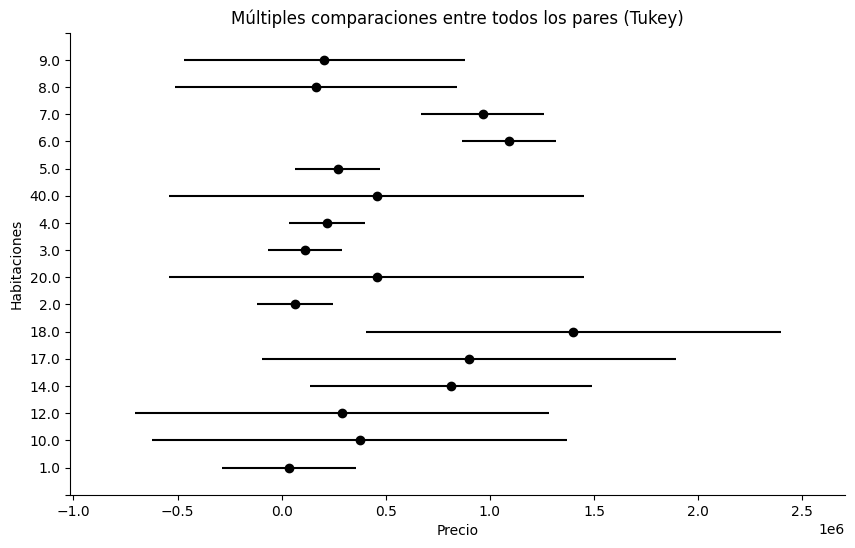

In [8]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Precio'], # Variable de respuesta (formerly Performance_Index)
    groups=df['Habitaciones'].astype(str),  # Variable categorica nominal (formerly Extracurricular_Activities)
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Habitaciones", xlabel="Precio")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [10]:
df["Extracurricular_Activities"] = df["Extracurricular_Activities"].map({
    "No": 0,
    "Yes": 1
})

df

KeyError: 'Extracurricular_Activities'

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1658 entries, 0 to 1982
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.2  1658 non-null   int64  
 1   Unnamed: 0    1658 non-null   int64  
 2   Unnamed: 0.1  1658 non-null   int64  
 3   Ubicación     1658 non-null   object 
 4   Area          1658 non-null   float64
 5   Baños         1658 non-null   float64
 6   Habitaciones  1658 non-null   float64
 7   Precio        1658 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 116.6+ KB


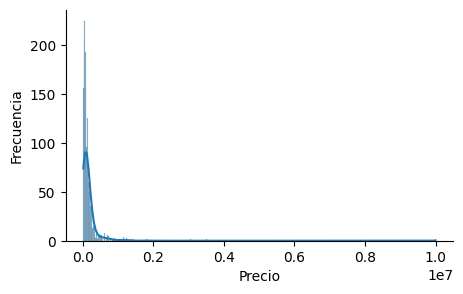

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Precio'], kde=True)
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

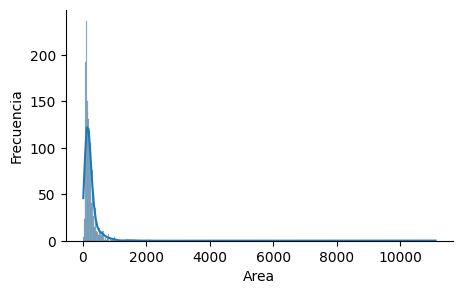

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Area'], kde=True)
plt.xlabel("Area")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

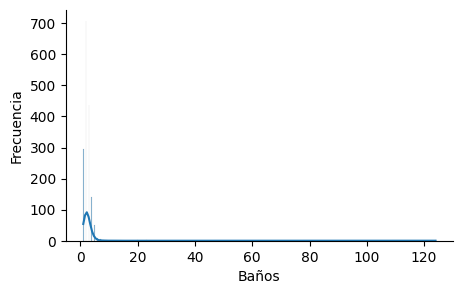

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Baños'], kde=True)
plt.xlabel("Baños")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

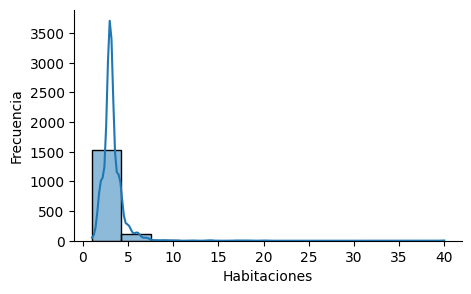

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Habitaciones'], kde=True)
plt.xlabel("Habitaciones")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

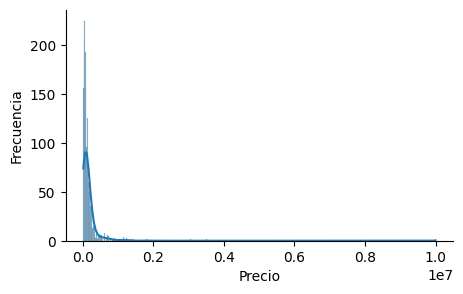

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(
    figsize=(5,3),
    dpi = 100
)
sns.histplot(df['Precio'], kde=True)
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.show()

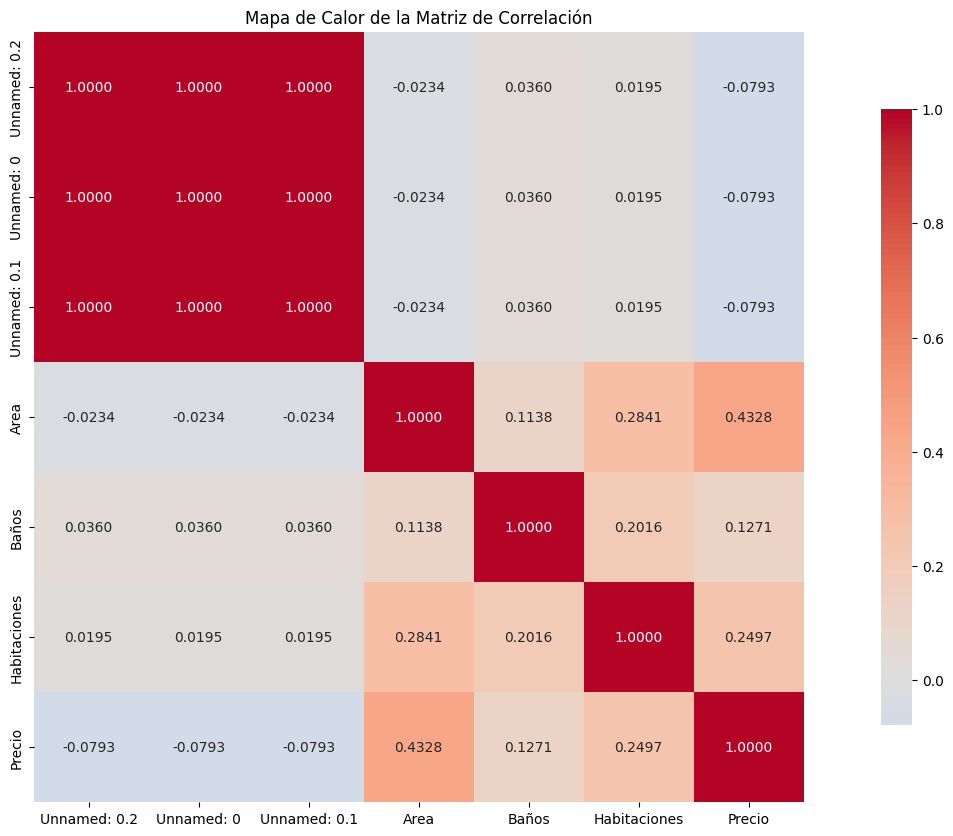

In [26]:
import seaborn as sns          # Librería para visualización estadística
import matplotlib.pyplot as plt  # Librería base para gráficos

# Calcula la matriz de correlación entre variables numéricas del DataFrame
correlation_matrix = df.corr(numeric_only=True)

plt.figure(
    figsize=(20, 10), # Define el tamaño de la figura (ancho, alto)
    dpi = 100  # Calidad de la imagen dpi=50 (estandar) dpi = 300 (alta calidad)
    )

# Construye el mapa de calor de la matriz de correlación
sns.heatmap(
    correlation_matrix,   # Datos: matriz de correlación
    annot=True,           # Muestra los valores numéricos en cada celda
    cmap='coolwarm',      # Paleta de colores (azul = negativo, rojo = positivo)
    fmt=".4f",            # Formato de los números (4 decimales)
    square=True,          # Hace que cada celda sea cuadrada
    center=0,             # Centra la escala de colores en 0 (muy importante)
    cbar_kws={"shrink": .8}  # Reduce el tamaño de la barra de color
)

# Título del gráfico
plt.title('Mapa de Calor de la Matriz de Correlación')

# Muestra la gráfica en pantalla
plt.show()

In [29]:
X = df["Area"]
Y = df["Precio"]

In [30]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [31]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  18.73%


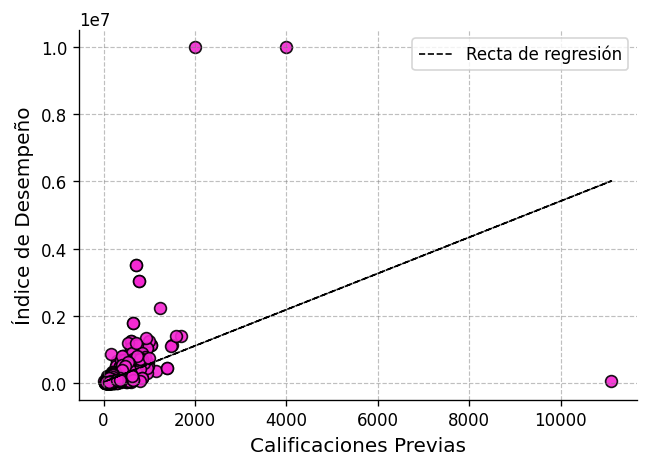

In [32]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Calificaciones Previas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Índice de Desempeño', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

In [33]:
residuales = modelo.resid

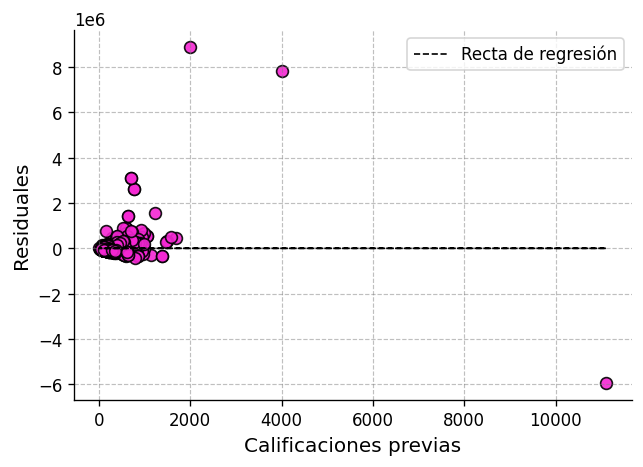

In [34]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Calificaciones previas', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

valor-p (Shapiro) = 1.7750326635588116e-64


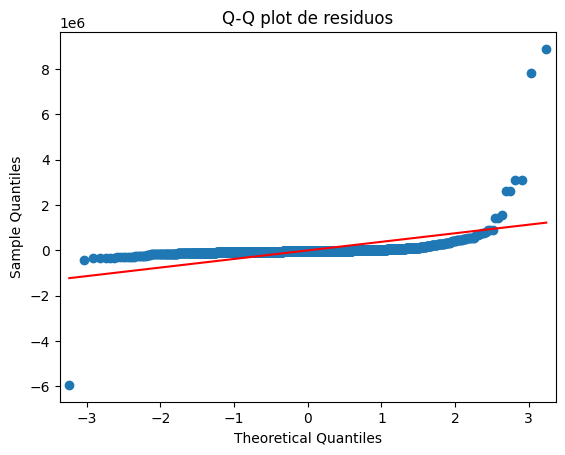

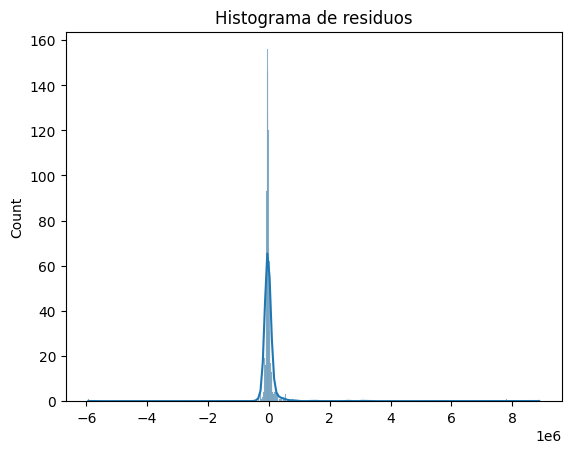

In [35]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [36]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000



In [39]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''Precio ~ Area''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Area,1.0,5.463166e+13,5.463166e+13,381.773778,1.136849e-76
Residual,1656.0,2.369729e+14,1.430996e+11,NaN,NaN


In [45]:
X = df[["Area", "Habitaciones"]]
Y = df["Precio"]

In [46]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [47]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  20.48%
